# From Zero to Quantum | Use A Quantum Computer Today | Ep.1

## Notebook Purpose

This notebook restructures the educational lesson/video into a Jupyter Notebook learning format. It is designed to preserve the original code exactly as presented in the official IBM Quantum Learning notebook for the lesson, while adding structured documentation around the conceptual flow.


## Metadata Block

| Field | Details |
|---|---|
| Video title | From Zero to Quantum \| Use A Quantum Computer Today \| Ep.1 |
| Lesson title | Build and run your first quantum program |
| Course | Use a quantum computer today |
| Presenter / Instructor | Olivia Lanes |
| Organisation / Source | IBM Quantum / Qiskit |
| YouTube URL | https://www.youtube.com/watch?v=vSFv_i_FAXg&t=2s |
| Official lesson URL | https://quantum.cloud.ibm.com/learning/en/courses/use-a-qc-today/build-and-run-your-first-quantum-program |
| Official notebook source | IBM Quantum Learning downloadable notebook |
| Main topic | Running a first quantum program using Qiskit |
| Core outcome | Create a two-qubit Bell state circuit, run it on IBM quantum hardware or a simulator, and visualise measurement results |
| Code fidelity note | Code cells below preserve the official lesson code. No refactoring or extra scenarios have been added. |


## Key Concepts

### 1. Goal of the Lesson

The lesson introduces quantum computing from a practical, hands-on perspective. Its goal is to help a beginner run code on a real quantum computer as quickly as possible, without requiring a physics degree or advanced mathematics background.

The lesson uses Qiskit and IBM Quantum services to build and execute a small quantum circuit. The central example is the creation of a two-qubit entangled state known as the $\Phi^+$ Bell state.

### 2. Qubits

A qubit is the basic unit of quantum computation, analogous to a classical bit in standard computing. A classical bit can be either `0` or `1`. A qubit, before measurement, can be described using amplitudes associated with possible outcomes.

This does not mean that a measurement will show both `0` and `1` at the same time. When measured, a qubit returns one classical result. The quantum behaviour becomes visible statistically after repeated runs.

### 3. Quantum Circuits

A quantum circuit is a sequence of operations applied to qubits. In a circuit diagram, qubits are shown as horizontal wires and quantum gates are shown as symbols or boxes placed on those wires.

The lesson first recommends using IBM Quantum Composer to visually understand circuits before writing equivalent Qiskit code by hand.

### 4. Hadamard Gate

The Hadamard gate, written as `H`, is used to place a qubit into an equal superposition. In this lesson, it is applied to qubit `0`.

Conceptually, this prepares the first qubit so that measurement outcomes are no longer deterministic; instead, they must be understood through probabilities.

### 5. CNOT / CX Gate

The controlled-NOT gate, written in Qiskit as `cx`, acts on two qubits: a control qubit and a target qubit.

In this lesson, `bell.cx(0, 1)` uses qubit `0` as the control and qubit `1` as the target. After applying the Hadamard gate followed by the CX gate, the two qubits become entangled.

### 6. Entanglement

Entanglement is a quantum relationship between qubits where their measurement outcomes become strongly correlated. For the $\Phi^+$ Bell state, the expected dominant outcomes are `00` and `11`.

This means that if the first qubit is measured as `0`, the second is also expected to be `0`; if the first is measured as `1`, the second is also expected to be `1`.

### 7. Measurement

Measurement converts quantum information into classical information. A single measurement gives one classical bitstring result, such as `00`, `01`, `10`, or `11`.

Because quantum measurement is probabilistic, the circuit must be run many times to estimate the underlying distribution.

### 8. Shots

A shot is one execution of the circuit followed by measurement. Running a circuit for many shots allows us to build a histogram of outcomes.

In this lesson, the circuit is run for `1000` shots. The expected Bell-state result is an approximately equal distribution between `00` and `11`.

### 9. Simulator vs Real Quantum Hardware

The simulator is an idealised environment that runs the circuit on a classical computer. It should show mostly or only the expected Bell-state outcomes, depending on the simulation model.

A real IBM quantum processing unit, or QPU, is physical hardware. Real devices include noise, imperfect gates, measurement error, calibration drift, queue time, and backend-specific constraints. Therefore, real QPU results may include small counts for `01` and `10` even when the ideal circuit predicts only `00` and `11`.

### 10. Transpilation and Backend Execution

Before a circuit runs on a backend, it may need to be transformed into a form compatible with the target device. This process is handled with Qiskit's preset pass manager.

The helper function in the lesson handles transpilation, execution through the `Sampler` primitive, and extraction of measurement counts.


## Related Topics for Further Study

- Bell states and Bell basis
- Quantum entanglement and non-classical correlation
- Superposition versus classical probability
- Quantum measurement and Born-rule statistics
- IBM Quantum Composer
- Qiskit circuit model
- Qiskit Runtime primitives
- Sampler primitive
- Quantum circuit transpilation
- Backend constraints and coupling maps
- Quantum hardware noise
- Shot count and statistical sampling
- Simulator-based testing versus QPU execution
- Error mitigation and calibration drift
- Quantum information basics
- Quantum algorithms that use entanglement as a resource


## Code Documentation: Installation and Imports

This cell installs the Qiskit packages required for the lesson and imports the exact classes and functions used later.

- `QuantumCircuit` is used to define qubits and quantum operations.
- `plot_histogram` visualises measurement counts.
- `AerSimulator` provides a simulator backend.
- `generate_preset_pass_manager` prepares circuits for a target backend.
- `Sampler` and `QiskitRuntimeService` are used to run circuits through IBM Quantum Runtime.

The code below is preserved from the official lesson.


**Part 1: Environment Setup and Validation**  
**Cell 1: Installation**  
First, we install the core Qiskit packages. This includes qiskit for circuit building, qiskit-aer for local simulation, and qiskit-ibm-runtime to access real hardware.

In [ ]:
# Install Qiskit and related tools
# !pip install qiskit qiskit-aer qiskit-ibm-runtime matplotlib pylatexenc

In [3]:
# Core Qiskit imports
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# IBM Runtime specific imports
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService

## Code Documentation: Environment Check

This cell confirms the Python and Qiskit-related package versions being used. It is included early so dependency or installation issues can be detected before running the quantum circuit.

The output shown in the official lesson used:
May 2026
```text
Python: 3.12.2
qiskit: 2.2.3
qiskit-aer: 0.17.2
qiskit-ibm-runtime: 0.41.1
```

The code below is preserved from the official lesson.

In [4]:
import sys

import qiskit
import qiskit_aer
import qiskit_ibm_runtime

print("Python:", sys.version.split()[0])
print("qiskit:", qiskit.__version__)
print("qiskit-aer:", qiskit_aer.__version__)
print("qiskit-ibm-runtime:", qiskit_ibm_runtime.__version__)

Python: 3.12.12
qiskit: 2.2.3
qiskit-aer: 0.17.2
qiskit-ibm-runtime: 0.45.0


## A Brief Side Quest: IBM Quantum Composer

Before writing code, the lesson recommends using IBM Quantum Composer to build circuits visually. Composer helps beginners understand what the gates do before focusing on syntax.

The visual circuit introduces:

- the `H` gate, which creates superposition;
- the CNOT/CX gate, which creates entanglement;
- measurement, which gives classical bitstring outcomes;
- shots, which are repeated circuit executions used to estimate probabilities.

### Check Your Understanding

**Can you see a superposition directly from a single measurement?**  
No. A single measurement returns a classical result: either `0` or `1`. The superposition becomes visible through statistics across many shots.

**What does entanglement give you in plain language?**  
It gives linked outcomes. Measuring one qubit tells you something about the other.

**What should the Composer histogram show for the Hello World Bell circuit?**  
It should show approximately 50% probability for `00` and 50% probability for `11`, which reflects the correlation produced by entanglement.


## Code Documentation: Build the Bell Circuit

This cell creates the $\Phi^+$ Bell state circuit.

The sequence is:

1. Create a two-qubit circuit using `QuantumCircuit(2)`.
2. Apply a Hadamard gate to qubit `0` using `bell.h(0)`.
3. Apply a controlled-NOT gate from qubit `0` to qubit `1` using `bell.cx(0, 1)`.
4. Measure all qubits using `bell.measure_all()`.
5. Draw the circuit using Matplotlib.

The code below is preserved from the official lesson.


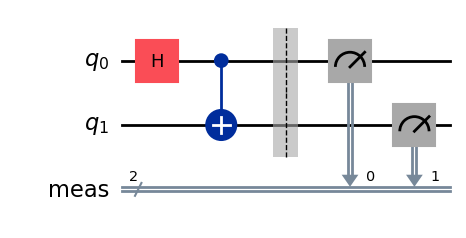

In [5]:
# --- Build the Bell circuit (phi-plus) ---
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all() # creates a classical register named "meas"

bell.draw("mpl")

## Code Documentation: Helper Function for Running Circuits

This function runs a quantum circuit on a chosen backend and returns measurement counts.

It performs three important steps:

1. Builds a preset pass manager for the backend.
2. Transpiles the circuit into an instruction-set architecture-compatible circuit.
3. Runs the transpiled circuit using the `Sampler` primitive and returns the measured counts.

The code below is preserved from the official lesson.


In [6]:
def run_circuit_and_get_counts(circuit, backend, shots=1000):
 """
 Runs a quantum circuit on a specified backend and returns the measurement counts.

 Args:
 circuit (QuantumCircuit): The quantum circuit to run.
 backend: The Qiskit backend (real device or simulator).
 shots (int): The number of shots to run the circuit.

 Returns:
 dict: A dictionary of measurement counts.
 """
 pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
 isa_circuit = pm.run(circuit)

 sampler = Sampler(mode=backend)

 job = sampler.run([isa_circuit], shots=shots)
 result = job.result()

 return result[0].data.meas.get_counts()

## Code Documentation: Run on a Real IBM Quantum Processing Unit

This section runs the Bell circuit on IBM quantum hardware.

Important notes:

- You must have an IBM Quantum Platform account.
- Put your IBM Quantum API token in `Utils/ibm_credentials.py`.
- The local credentials file is ignored by git so your token is not exposed.
- The backend is selected using `service.least_busy(...)` with a minimum of 127 qubits.
- In the official lesson output, the selected backend printed as `ibm_pittsburgh`.

Because real QPUs are noisy, the histogram should show mostly `00` and `11`, but may also contain small counts for `01` and `10`.

The code below is preserved from the official lesson.


In [7]:
# Syntax for first saving your token. Keep the token in Utils/ibm_credentials.py.
# You only need to do this once, and then you can load the saved credentials in the next step.
# example : IBM_QUANTUM_TOKEN = "your_ibm_quantum_token_here"
from pathlib import Path
import sys

credentials_dir = Path("../Utils")
if not credentials_dir.exists():
    credentials_dir = Path("Utils")
sys.path.insert(0, str(credentials_dir.resolve()))

from ibm_credentials import IBM_QUANTUM_TOKEN

QiskitRuntimeService.save_account(
 channel="ibm_quantum_platform",
 token=IBM_QUANTUM_TOKEN,
 overwrite=True,
 set_as_default=True,
)
service = QiskitRuntimeService(channel="ibm_quantum_platform")

# Load saved credentials
service = QiskitRuntimeService()

# Use the least busy backend, or uncomment the loading of a specific backend like "ibm_fez".
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
# backend = service.backend("ibm_fez")
print(backend.name)

qiskit_runtime_service.__init__:WARNING:2026-05-16 01:10:19,110: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: ibm_qgss2025_dkt_ca. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.__init__:WARNING:2026-05-16 01:10:23,443: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: ibm_qgss2025_dkt_ca. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backend

ibm_marrakesh


## Code Documentation: Visualise Real QPU Results

This cell executes the Bell circuit on the selected IBM backend for `1000` shots and visualises the measurement counts.

Expected real-hardware behaviour:

- `00` and `11` should dominate.
- `01` and `10` may appear due to hardware noise, gate error, measurement error, or device calibration effects.

The code below is preserved from the official lesson.


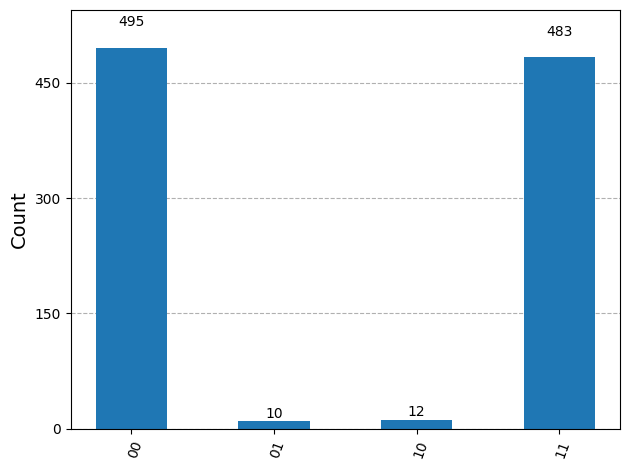

In [8]:
counts = run_circuit_and_get_counts(bell, backend, shots=1000)
plot_histogram(counts)

## Code Documentation: Run on a Simulator

This cell runs the same Bell circuit on `AerSimulator`.

The simulator is described in the lesson as a “perfect world” version of quantum computing. It should produce approximately equal counts for `00` and `11` and no `01` or `10` results for the ideal Bell-state circuit.

The exact count split may not be exactly 500/500 because the simulator is still sampling a probabilistic process over `1000` shots.

The code below is preserved from the official lesson.


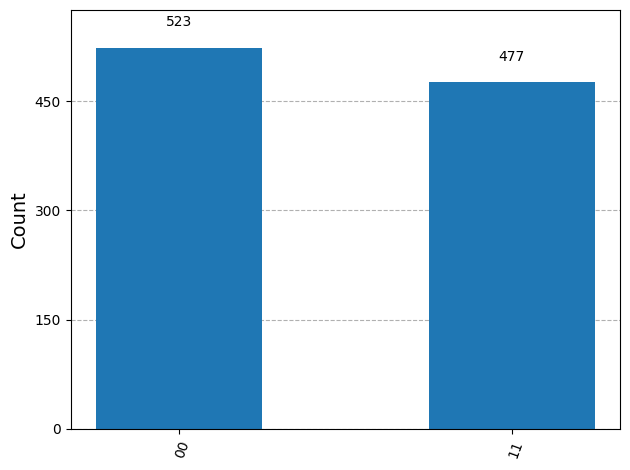

In [9]:
backend = AerSimulator()
counts = run_circuit_and_get_counts(bell, backend, shots=1000)

plot_histogram(counts)

## Check Your Understanding

### What are the two gates that create the Bell state here?

An `H` gate on qubit `0`, followed by a `CX` gate with qubit `0` as the control and qubit `1` as the target.

### On an ideal simulator, which two bitstrings should dominate the histogram?

`00` and `11`.

### Why would a perfect simulator not always show exactly the same number of `00` and `11` counts?

Because the process is probabilistic. Even with an exact 50/50 probability distribution, finite sampling over `1000` shots can produce statistical fluctuations.

### Why might a real quantum computer show some `01` or `10` results?

Because real devices have noise. Gates and measurements are not perfect, and occasional errors may appear in the results.

### What is one practical difference between simulators and real quantum computers besides noise?

Real quantum computers may involve queue time, limited availability, and device-specific constraints.


## Conclusion

This lesson begins with Qiskit setup, introduces the visual model of quantum circuits through IBM Quantum Composer, and then builds a two-qubit Bell circuit by hand.

The main technical result is the creation of the $\Phi^+$ Bell state using a Hadamard gate followed by a controlled-NOT gate. The lesson then compares execution on a real IBM QPU with execution on a simulator.

The key learning outcome is that entanglement appears as correlation in measurement statistics: the Bell circuit produces dominant `00` and `11` outcomes. On a simulator this correlation should appear cleanly; on real hardware, small error counts may appear due to noise.

## Fidelity and Limitation Note

The code included in this notebook is taken from the official IBM Quantum Learning notebook for this video lesson. I did not add new code scenarios, refactor the cells, or change the lesson context. Conceptual explanations were expanded into notebook documentation form.
